In [ ]:
%pip install tqdm
%pip install joblib
%pip install tensorflow
%pip install -U hats lsdb
%pip install "dask[complete]"
%pip install 'light-curve[full]'

In [2]:
import os
import time
import logging
import warnings
import traceback
import numpy as np
import pandas as pd
from tqdm import tqdm
import tensorflow as tf
from lsdb import read_hats
import matplotlib.pyplot as plt
from dask.distributed import Client
from joblib import Parallel, delayed
from nested_pandas import NestedDtype
from joblib import wrap_non_picklable_objects
from dart.bands.bands import ztf_band

warnings.filterwarnings(action="ignore") 
logging.getLogger('tensorflow').setLevel(logging.ERROR)  

In [45]:
def standardize(x, err):

    mean = np.average(x, weights=1/err**2)
    x_ = x - mean
    return x_

def get_record(id_, label, last_index, numpy_lc):
    """
    Create tf.records from numpy values.

    Parameters:
    ---------------------------------------------------------------------
        id_ (int): object id (_healpix_29)
        label (str): class 
        numpy_lc (numpy array): time, magnitudes, mag error, band info
    ---------------------------------------------------------------------
    Returns:
        tensorflow record
        
    """
    dict_sequence = {}
    dict_features={
    'id': tf.train.Feature(int64_list=tf.train.Int64List(value=[id_])),
    'label': tf.train.Feature(bytes_list=tf.train.BytesList(value=[str(label).encode()])),
    'last_index': tf.train.Feature(int64_list=tf.train.Int64List(value=list(last_index.values()))),
    'bands': tf.train.Feature(bytes_list=tf.train.BytesList(value=[k.encode('utf-8') for k in last_index.keys()])) 
    }
    
    element_context = tf.train.Features(feature = dict_features)

    for col in range(numpy_lc.shape[1]):
        seqfeat = tf.train.Feature(float_list=tf.train.FloatList(value=numpy_lc[:, col]))
        seqfeat = tf.train.FeatureList(feature = [seqfeat])
        dict_sequence['dim_{}'.format(col)] = seqfeat

    element_lists = tf.train.FeatureLists(feature_list=dict_sequence)
    rec = tf.train.SequenceExample(context = element_context,
                                  feature_lists= element_lists)
    return rec


def train_test_split(frame, train_size, seed):
    """
    Divide the dataset into train, validation and test subsets.
    Note:
        val_size = 1 - train_size
        test_size = train_size + val_size (entire dataset)

    Parameters:
    -----------------------------------------------------------------------
        frame (Dataframe): Dataframe following the astro-standard format
        train_size (float): train fraction
        seed (int): set seed (default=42)
    -----------------------------------------------------------------------
    Returns:
        tuple : (name of subset, subframe with metadata)

    """

    frame = frame.sample(frac=1, random_state=seed)
    n_samples = frame.shape[0]
    
    if n_samples == 0: 
        return ('train', None), ('val', None), ('test', None)
    
    elif n_samples == 1: 
        sub_test  = frame.iloc[:]
        sub_train = frame.iloc[:]
        sub_val   = None
    else:
        n_train = int(n_samples*train_size)
        sub_test  = frame.iloc[:]
        sub_train = frame.iloc[:n_train]
        sub_val   = frame.iloc[n_train:]
    
    return ('train', sub_train), ('val', sub_val), ('test', sub_test)



def create_record(id_, label, last_index, numpy_lc, writer):
    """
    Parameters:
    ---------------------------------------------------------------
        id_ (int): index of the lightcurve (_healpix_29)
        label (str): class name
        last_index (dict): last index of each band
        numpy_lc (numpy array): lightcurve data

    """
    try:
        rec = get_record(id_, label, last_index, numpy_lc)
        writer.write(rec.SerializeToString())
    except Exception as e:
        print(f'\nException raised: {id_} could not be processed in create_record().\n')


@wrap_non_picklable_objects
def process_lc(id_, row, bands, min_detec):
    """
    Process each light curve

    Parameters:
    ------------------------------------------------------------------------------
        id_ (int): index of the lightcurve (_healpix_29)
        row (DataFrame): lightcurve data
        bands (dict): band information (filters should be in a ordered sequence)
                        e.g. ZTF band order is {g, r, i}, meaning g-filter 
                        has the highest priority and i-filter has the lowest.
        min_detec (int): minimum detections in each light curve
                        Note: For ZTF, "min_detec" for g & r-filters is user-defined
                        but, for i-filter there is no min_detec 
                        (it's set to 0 based on the band order in the band dict)
    -------------------------------------------------------------------------------
    Returns:
        id_ (int): index of the lightcurve (_healpix_29)
        label (str): class name
        last_index (dict): last index of each band
        numpy_lc (numpy array): lightcurve data

    """
    #
    # Store the last index of each band 
    #
    last_index = dict()
    #
    # Store the label of the lightcurve
    #
    label = row["Class"]
    #
    # Filter the "lc" column from the catalog and convert it to a DataFrame
    #
    row_ = row["lc"]  
    temp_df = pd.DataFrame(row_)
    try:
        #
        # Filter the non-empty lightcurve 
        #
        if not temp_df.isnull().values.all():  
            #
            # Sort the lightcurve by band in the following order: g, r, i
            #
            temp_df = temp_df.dropna()
            temp_df['band_sorted'] = pd.Categorical( temp_df['band'], 
                                            categories=list(bands.keys()), 
                                            ordered=True
                                            )
            temp_df = temp_df.sort_values(['band_sorted', 'mjd'])
            temp_df = temp_df.reset_index(drop=True)
            temp_df.drop(columns=['band'], inplace=True)
            #
            # Store the last index of each band in the dictionary "last_index"
            #
            end_idx = 0
            #
            for i, k in enumerate(bands.keys()):
                #
                n_samples = temp_df[temp_df["band_sorted"] == k].shape[0]
                #
                if (n_samples >= min_detec) | (i == len(bands.keys())-1):
                    end_idx = n_samples + end_idx
                    last_index[k] = end_idx -1
                else:
                    return None
                    
            temp_df = temp_df.replace({"band_sorted":bands})
            temp_df = temp_df[["mjd", "mag", "magerr", "band_sorted"]]
            numpy_lc = temp_df.to_numpy()
            #
            return id_, label, last_index, numpy_lc

    
    except Exception:
        raise Exception(f'\nException raised: {id_} could not be processed in process_lc().\n') 
        
        
        
def write_records(frame, dest, max_lcs_per_chunk, n_jobs, bands, min_detec, n_partition):
    """
    Get frames with fixed number of lightcurves in each chunk

    Parameters:
    -----------------------------------------------
        bands (dict): band information (filters should be in a ordered sequence)
                        e.g. ZTF band order is {g, r, i}, meaning g-filter 
                        has the highest priority and i-filter has the lowest.
        frame (dataframe): catalog data
        dest (str): path to store the files
        n_jobs (int): # of parallel jobs
        min_detec (int): minimum detections in each light curve
                        Note: For ZTF, "min_detec" for g & r-filters is user-defined
                        but, for i-filter there is no min_detec 
                        (it's set to 0 based on the filter order in the bands dict)
        max_lcs_per_chunk (int): # of lcs to be stored in a chunk

    """
    #
    # 
    #
    collection = [frame.iloc[i:i+max_lcs_per_chunk] \
                  for i in range(0, frame.shape[0], max_lcs_per_chunk)]

    for counter, subframe in enumerate(collection):
        var = Parallel(n_jobs=n_jobs)(delayed(process_lc)(id_, row, bands, min_detec) \
                                    for id_, row in subframe.iterrows())

        with tf.io.TFRecordWriter(dest+f"/chunk_{n_partition}_{counter}.record") as writer:
            for _, data_lc in enumerate(var):
                if data_lc is not None:
                    create_record(*data_lc, writer)


In [46]:
def create_dataset(df,
                    target,
                    njobs=1,
                    bands=None,
                    seed=42,
                    min_detec=100,
                    train_size=0.80,
                    max_lcs_per_chunk=100,
                    partition_info=None):
    
    """
    Create tf.records from the catalog

    Parameters: 
    ---------------------------------------------------------
        df (DataFrame): contains the catalog file
        target (str): directory path for the files to be stored
        bands (dict): band information (filters should be in a ordered sequence)
                        e.g. ZTF band order is {g, r, i}, meaning g-filter 
                        has the highest priority and i-filter has the lowest.
        n_jobs (int): # of parallel jobs
        train_size (float): train fraction
        min_detec (int): minimum detections in each light curve
                        Note: For ZTF, "min_detec" for g & r-filters is user-defined
                        but, for i-filter there is no min_detec 
                        (it's set to 0 based on the filter order in the bands dict)
        max_lcs_per_chunk (int): # of lcs to be stored in a chunk
        
    """
    #
    # First partition_info in None
    # Start from the 2nd partition_info
    #
    if partition_info is not None:
        info_df = pd.DataFrame()
        LC_COLUMN = "lc"
        n_partition = partition_info['number']
        str_div = partition_info['division']
        #
        #
        #
        try: 
            if not train_size or train_size > 1:
                raise ValueError(f"Please provide a valid train_size fraction (between 0-1). Got {train_size}")
            
            if bands is None:
                raise ValueError(f"Please provide band information with ordered filters. Got {bands}")
            
            if not os.path.exists(target):
                os.makedirs(target, exist_ok=True)
            #
            dest = os.path.join(target, "objects")
            os.makedirs(dest, exist_ok=True)
            #
            df = df.assign(**{LC_COLUMN: df[LC_COLUMN].astype(NestedDtype.from_pandas_arrow_dtype(df.dtypes[LC_COLUMN]))},)
            df = df.dropna(subset=['lc'])
            #
            # Save the number of classes and their counts in a .CSV file
            #
            unique, counts = np.unique(df['Class'], return_counts=True)
            info_df['label'] = unique
            info_df['size'] = counts
            info_df['start_index'] = str_div
            info_df.to_csv(os.path.join(target, "objects", f'partition_{n_partition}.csv'), index=False)
            #
            # Separate by class
            #
            cls_groups = df.groupby('Class')
            #
            # Write lcs in the records
            #
            for cls_name, cls_meta in tqdm(cls_groups, total=len(cls_groups)):
                subsets = train_test_split(cls_meta, train_size=train_size, seed=seed)

                for subset_name, frame in subsets:
                    if frame is None:
                        continue
                    dest = os.path.join(target, subset_name, f"partition_{n_partition}", cls_name)
                    os.makedirs(dest, exist_ok=True)
                    write_records(frame, dest, max_lcs_per_chunk, n_jobs=njobs, 
                                  bands=bands, min_detec=min_detec, n_partition=n_partition)

        except Exception:
            print(f"\n\n[Traceback]\n",traceback.format_exc())
            


In [11]:
#
# Read catalog
#
read_catalog = read_hats('../../dataset/cepheids/hats/zubercal_vcep', )

In [ ]:
#
# Read catalog
#
read_catalog = read_hats('./rrlyrae/hats/zubercal_vrrlyr', )
#    
print("\nStarting!")
start = time.time()
#
#
#
path_to_store="./rrlyrae/"
#
#
#
catalog_compute = read_catalog._ddf.map_partitions(create_dataset, 
                                                        target=path_to_store,
                                                        bands=ztf_band,
                                                        seed=42,
                                                        min_detec=100,
                                                        train_size=.80,
                                                        max_lcs_per_chunk=100)

with Client() as client:
    display(client)
    catalog_compute.compute(scheduler='processes')

end = time.time()
print("\nTime (mins):", ((end-start)//60))
print("\nDone!")

    

In [56]:
#
#
#
hist = dict()
labels = list()
chunks = list()
filenames = list()
path = f"./rrlyrae/train/"
#
#
#
for p in os.listdir(path):
    for lbl in os.listdir(path+p):
        for cnk in os.listdir(path+p+"/"+lbl):
            filenames.append(path+p+"/"+lbl+'/'+cnk)
# print(filenames)
#
#
#
for k in ztf_band.keys():
    hist[k] = list()

for f in filenames:
    #
    #
    #
    dataset = tf.data.TFRecordDataset(f)
    #
    #
    #
    for rec in dataset:
        #
        example = tf.train.SequenceExample()
        example.ParseFromString(rec.numpy())
        #
        last_index = example.context.feature['last_index'].int64_list.value
        time = example.feature_lists.feature_list['dim_0'].feature[0].float_list.value
        mag = example.feature_lists.feature_list['dim_1'].feature[0].float_list.value
        band_sorted = example.feature_lists.feature_list['dim_3'].feature[0].float_list.value
        last_index = example.context.feature['last_index'].int64_list.value
        id = example.context.feature['id'].int64_list.value[0]
        
        # 
        j=0
        for i, l in enumerate(hist.keys()):
            #
            temp = last_index[i]+1
            length = temp-j
            hist[l].append(length)
            j = temp
            # print(l, length)
        

# print(hist)

In [ ]:
l=[]
for i in hist['g']:
    if i == 0:
        l.append(i)
print(l)
print(len(l))
print(len(hist['g']))

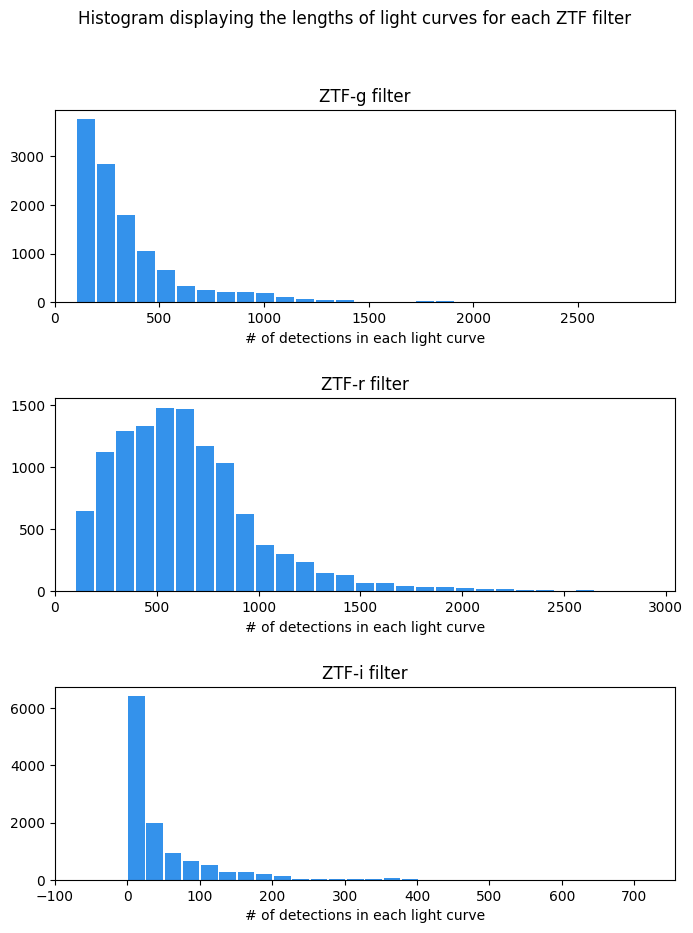

In [55]:
#
#
#
plt.figure(figsize=(8, 10))
plt.suptitle(f"Histogram displaying the lengths of light curves for each ZTF filter")
for i , k in enumerate(hist.keys()):
    # 
    # list_to_array = np.array(hist[k])
    # idx = np.where(list_to_array <= 10)
    plt.subplot(3, 1, i+1)
    plt.hist(hist[k], bins=30, color="#3492eb", rwidth=0.9)
    plt.xlim(min(hist[k])-100, max(hist[k]))
    # print(min(hist[k]), max(hist[k]), len(hist[k]))
    plt.title(f"ZTF-{k} filter")
    plt.subplots_adjust(hspace=0.5)
    plt.xlabel("# of detections in each light curve")
# plt.savefig("./cephids/length.png")